# 🦴 MedSAM — Segmentación Vertebral T1–L5 (v2)

**Notebook alterno al pipeline YOLOv8-seg** para segmentación de vértebras
en radiografías AP de columna con escoliosis.

### Cambios en v2:
- ✅ Columnas correctas del CSV índice (`grupo`, `ruta_radiografia`, `ruta_mascara_multiclase_id_png`)
- ✅ Filtrado rápido usando `reporte_por_mascara_version_final.csv` (sin abrir imágenes)
- ✅ Exclusión automática de máscaras vacías (ej: S_107)
- ✅ Compatibilidad con PyTorch 2.10+ (`total_memory`)

### Archivos que usa el notebook:
| Archivo | Uso |
|---|---|
| `indice_dataset.csv` | Mapeo imagen ↔ máscara |
| `reporte_por_mascara_version_final.csv` | Filtrado rápido por calidad |
| `Normal/*.jpg` + `Scoliosis/*.jpg` | Radiografías (input) |
| `LabelMultiClass_ID_PNG/*.png` | Máscaras multiclase (ground truth) |

### Archivos que **NO** usa:
| Archivo | Razón |
|---|---|
| `LabelMultiClass_Color_JPG/` | Solo visualización, JPG destruye bordes |
| `LabelMultiClass_Gray_JPG/` | Redundante con Color |
| `LabelBinaryJPG/` | No distingue vértebras individuales |
| Carpeta `MedSAM/` | Experimento anterior |

## 0 — Instalación y Setup

In [1]:
!pip install -q transformers monai nibabel opencv-python-headless matplotlib scikit-learn tqdm
!pip install -q git+https://github.com/bowang-lab/MedSAM.git

import torch
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print(f'PyTorch: {torch.__version__}')
if torch.cuda.is_available():
    print(f'GPU:     {torch.cuda.get_device_name(0)}')
    print(f'VRAM:    {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    DEVICE = torch.device('cuda')
else:
    print('⚠️ No GPU detected — will use CPU (much slower)')
    DEVICE = torch.device('cpu')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 28.0 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
PyTorch: 2.10.0+cu128
GPU:     Tesla T4
VRAM:    15.6 GB


In [7]:
# ── CONFIGURACIÓN ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── RUTAS (ajustar según entorno) ──────────────────────────
# Kaggle:
# DATASET_ROOT = Path('/kaggle/input/scoliosis-dataset')
# Colab:
# from google.colab import drive
# drive.mount('/content/drive')
# DATASET_ROOT = Path('/content/drive/MyDrive/Scoliosis_Dataset')

DATASET_ROOT = Path('/kaggle/input/datasets/javiercamilogarcia/scoliosis-dataset')  # ← AJUSTAR

# ── CSVs ──────────────────────────────────────────────────
CSV_INDICE  = DATASET_ROOT / 'indice_dataset.csv'
CSV_REPORTE = DATASET_ROOT / 'reporte_por_mascara_version_final.csv'

WORK_DIR = Path('/kaggle/working/medsam_spine')  # ← AJUSTAR si Colab
WORK_DIR.mkdir(parents=True, exist_ok=True)

# ── COLUMNAS CORRECTAS DEL CSV ────────────────────────────
COL_GRUPO = 'grupo'                            # 'Normal' / 'Scoliosis'
COL_IMAGE = 'ruta_radiografia'                 # Normal/N_1.jpg
COL_MASK  = 'ruta_mascara_multiclase_id_png'   # LabelMultiClass_ID_PNG/LabelMulti_N_1.png

# ── CLASES VERTEBRALES ────────────────────────────────────
CLASS_NAMES = [
    'T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12',
    'L1','L2','L3','L4','L5'
]
NUM_CLASSES = 17
MEDSAM_IMG_SIZE = 1024

print('✔ Configuración lista')

✔ Configuración lista


In [8]:
#import os
#for root, dirs, files in os.walk('/kaggle/input'):
 #   for file in files:
  #      print(os.path.join(root, file))

## 1 — Carga de Datos y Filtrado con Reporte

### ¿Por qué usar `reporte_por_mascara_version_final.csv`?

| Método | Velocidad | Qué hace |
|---|---|---|
| ❌ Abrir cada PNG | ~3-5 min | Lee cada máscara con cv2 y cuenta clases |
| ✅ Usar el reporte CSV | ~0.1 seg | Ya tiene pre-calculado cuántas vértebras hay |

In [9]:
# ── Cargar CSV índice ──
df = pd.read_csv(CSV_INDICE)  # separador = coma
print(f'Total imágenes en índice: {len(df)}')
print(f'\nDistribución por grupo:')
print(df[COL_GRUPO].value_counts().to_string())
print(f'\nColumnas disponibles:')
print(list(df.columns))

Total imágenes en índice: 250

Distribución por grupo:
grupo
Scoliosis    179
Normal        71

Columnas disponibles:
['grupo', 'imagen', 'id_paciente', 'ruta_radiografia', 'ruta_mascara_binaria', 'ruta_mascara_multiclase_id_png', 'ruta_mascara_multiclase_grises_jpg', 'ruta_mascara_multiclase_color_jpg', 'metricas_json']


In [10]:
# ── Cargar CSV reporte de máscaras ──
reporte = pd.read_csv(CSV_REPORTE)
print(f'Total máscaras en reporte: {len(reporte)}')
print(f'\nColumnas del reporte:')
print(list(reporte.columns))
print(f'\nDistribución de vértebras por máscara:')
print(reporte['numero_etiquetas_presentes_en_version_final'].describe().to_string())

Total máscaras en reporte: 250

Columnas del reporte:
['archivo_mascara', 'etiquetas_presentes_en_version_final', 'otras_etiquetas_identificadas_en_mascara_original', 'numero_otras_etiquetas_identificadas', 'numero_etiquetas_presentes_en_version_final']

Distribución de vértebras por máscara:
count    250.000000
mean      13.524000
std        3.772845
min        0.000000
25%       11.000000
50%       15.000000
75%       17.000000
max       17.000000


### 1.1 — Merge: índice + reporte

Unimos ambos CSVs por el nombre de archivo de máscara para tener
la ruta de la imagen + la info de calidad de la máscara en un solo DataFrame.

In [11]:
# ── Extraer nombre de archivo de máscara del índice ──
# ruta_mascara_multiclase_id_png = 'LabelMultiClass_ID_PNG/LabelMulti_N_1.png'
# archivo_mascara en reporte     = 'LabelMulti_N_1.png'
df['archivo_mascara'] = df[COL_MASK].apply(lambda x: Path(x).name if pd.notna(x) else '')

# ── Merge ──
df_merged = df.merge(reporte, on='archivo_mascara', how='left')

print(f'Registros después del merge: {len(df_merged)}')
print(f'\nPrimeras filas:')
df_merged[['imagen', COL_GRUPO, 'archivo_mascara',
           'numero_etiquetas_presentes_en_version_final']].head(10)

Registros después del merge: 250

Primeras filas:


,imagen,grupo,archivo_mascara,numero_etiquetas_presentes_en_version_final
0,N_1.jpg,Normal,LabelMulti_N_1.png,17
1,N_2.jpg,Normal,LabelMulti_N_2.png,17
2,N_3.jpg,Normal,LabelMulti_N_3.png,17
3,N_4.jpg,Normal,LabelMulti_N_4.png,17
4,N_5.jpg,Normal,LabelMulti_N_5.png,17
5,N_6.jpg,Normal,LabelMulti_N_6.png,17
6,N_7.jpg,Normal,LabelMulti_N_7.png,17
7,N_8.jpg,Normal,LabelMulti_N_8.png,17
8,N_9.jpg,Normal,LabelMulti_N_9.png,17
9,N_10.jpg,Normal,LabelMulti_N_10.png,17


### 1.2 — Filtrado por calidad

Filtramos usando el reporte:
- **Mínimo 13 vértebras** (T1 a L1) → consistente con notebook YOLOv8
- **Excluir máscaras vacías** (ej: `S_107` tiene 0 etiquetas)

In [12]:
MIN_VERTEBRAE = 13  # T1 a L1 mínimo

# ── Estado antes del filtrado ──
total_antes = len(df_merged)

# Identificar problemas
vacias = df_merged[df_merged['numero_etiquetas_presentes_en_version_final'] == 0]
incompletas = df_merged[
    (df_merged['numero_etiquetas_presentes_en_version_final'] > 0) &
    (df_merged['numero_etiquetas_presentes_en_version_final'] < MIN_VERTEBRAE)
]
sin_reporte = df_merged[df_merged['numero_etiquetas_presentes_en_version_final'].isna()]

print(f'=== RESUMEN DE FILTRADO ===')
print(f'Total imágenes:              {total_antes}')
print(f'Máscaras vacías (0 clases):  {len(vacias)}')
if len(vacias) > 0:
    print(f'  → {vacias["imagen"].tolist()}')
print(f'Incompletas (<{MIN_VERTEBRAE} clases): {len(incompletas)}')
print(f'Sin reporte (NaN):           {len(sin_reporte)}')

# ── Aplicar filtro ──
df_clean = df_merged[
    df_merged['numero_etiquetas_presentes_en_version_final'] >= MIN_VERTEBRAE
].reset_index(drop=True)

print(f'\n✔ Imágenes válidas después del filtrado: {len(df_clean)}/{total_antes}')
print(f'  Normal:    {len(df_clean[df_clean[COL_GRUPO]=="Normal"])}')
print(f'  Scoliosis: {len(df_clean[df_clean[COL_GRUPO]=="Scoliosis"])}')

=== RESUMEN DE FILTRADO ===
Total imágenes:              250
Máscaras vacías (0 clases):  1
  → ['S_107.jpg']
Incompletas (<13 clases): 85
Sin reporte (NaN):           0

✔ Imágenes válidas después del filtrado: 164/250
  Normal:    70
  Scoliosis: 94


### 1.3 — Split Train / Val / Test

In [13]:
# ── Split 70/15/15 estratificado por grupo ──
train_df, temp_df = train_test_split(
    df_clean, test_size=0.30, stratify=df_clean[COL_GRUPO], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df[COL_GRUPO], random_state=SEED
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Split final:')
for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    n = len(split[split[COL_GRUPO]=='Normal'])
    s = len(split[split[COL_GRUPO]=='Scoliosis'])
    print(f'  {name:5s}: {len(split):3d} imgs (Normal: {n}, Scoliosis: {s})')

Split final:
  Train: 114 imgs (Normal: 49, Scoliosis: 65)
  Val  :  25 imgs (Normal: 11, Scoliosis: 14)
  Test :  25 imgs (Normal: 10, Scoliosis: 15)


## 2 — Funciones de Preprocesamiento

In [14]:
def load_image_and_mask(row):
    """Carga imagen RGB y máscara multiclase desde las rutas del CSV."""
    img_path  = str(DATASET_ROOT / row[COL_IMAGE])
    mask_path = str(DATASET_ROOT / row[COL_MASK])
    img  = cv2.imread(img_path)
    img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
    if mask.ndim == 3:
        mask = mask[:, :, 0]
    return img, mask


def resize_for_medsam(img, mask, target_size=MEDSAM_IMG_SIZE):
    """Redimensiona imagen y máscara a 1024×1024 para MedSAM."""
    img_r  = cv2.resize(img,  (target_size, target_size), interpolation=cv2.INTER_LINEAR)
    mask_r = cv2.resize(mask, (target_size, target_size), interpolation=cv2.INTER_NEAREST)
    return img_r, mask_r


def get_bbox_from_mask(binary_mask, margin=5):
    """
    Extrae bounding box [x_min, y_min, x_max, y_max] de una máscara binaria.
    Añade margen para dar contexto al modelo.
    """
    h, w = binary_mask.shape
    ys, xs = np.where(binary_mask > 0)
    if len(xs) == 0 or len(ys) == 0:
        return None
    x_min = max(0, int(xs.min()) - margin)
    y_min = max(0, int(ys.min()) - margin)
    x_max = min(w, int(xs.max()) + margin)
    y_max = min(h, int(ys.max()) + margin)
    return [x_min, y_min, x_max, y_max]


def extract_vertebra_samples(df_split):
    """
    Extrae muestras individuales por cada vértebra en cada imagen.
    Retorna lista de dicts: {image, mask, bbox, class_id, class_name}
    """
    samples = []
    for _, row in tqdm(df_split.iterrows(), total=len(df_split), desc='Extrayendo muestras'):
        img, mask = load_image_and_mask(row)
        img_r, mask_r = resize_for_medsam(img, mask)
        for cls_id in range(1, NUM_CLASSES + 1):
            binary = (mask_r == cls_id).astype(np.uint8)
            if binary.sum() < 50:  # área mínima
                continue
            bbox = get_bbox_from_mask(binary)
            if bbox is None:
                continue
            samples.append({
                'image': img_r,
                'mask': binary,
                'bbox': bbox,
                'class_id': cls_id,
                'class_name': CLASS_NAMES[cls_id - 1],
            })
    print(f'  → {len(samples)} muestras de vértebras extraídas')
    return samples


# ── Extraer muestras ──
print('Extrayendo muestras de entrenamiento...')
train_samples = extract_vertebra_samples(train_df)
print('\nExtrayendo muestras de validación...')
val_samples = extract_vertebra_samples(val_df)
print('\nExtrayendo muestras de test...')
test_samples = extract_vertebra_samples(test_df)

Extrayendo muestras de entrenamiento...


Extrayendo muestras: 100%|██████████| 114/114 [00:11<00:00,  9.73it/s]


  → 1809 muestras de vértebras extraídas

Extrayendo muestras de validación...


Extrayendo muestras: 100%|██████████| 25/25 [00:02<00:00,  9.27it/s]


  → 402 muestras de vértebras extraídas

Extrayendo muestras de test...


Extrayendo muestras: 100%|██████████| 25/25 [00:02<00:00,  9.81it/s]

  → 388 muestras de vértebras extraídas


## 3 — Cargar Modelo MedSAM

Se descarga desde HuggingFace: `wanglab/medsam-vit-base` (~2.4 GB).
En Kaggle se puede precargarlo como Dataset para no descargarlo cada vez.

In [15]:
from transformers import SamModel, SamProcessor

MODEL_NAME = 'wanglab/medsam-vit-base'

print(f'Descargando {MODEL_NAME}...')
processor = SamProcessor.from_pretrained(MODEL_NAME)
model     = SamModel.from_pretrained(MODEL_NAME).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\n✔ MedSAM cargado')
print(f'  Parámetros totales:     {total_params:,}')
print(f'  Parámetros entrenables: {trainable:,}')

Descargando wanglab/medsam-vit-base...


preprocessor_config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

The image processor of type `SamImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/375M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/315 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared_image_embedding.positional_embedding to prompt_encoder.shared_embedding.positional_embedding, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


model.safetensors:   0%|          | 0.00/375M [00:00<?, ?B/s]


✔ MedSAM cargado
  Parámetros totales:     93,735,984
  Parámetros entrenables: 93,735,984


## 4 — Inferencia Zero-Shot

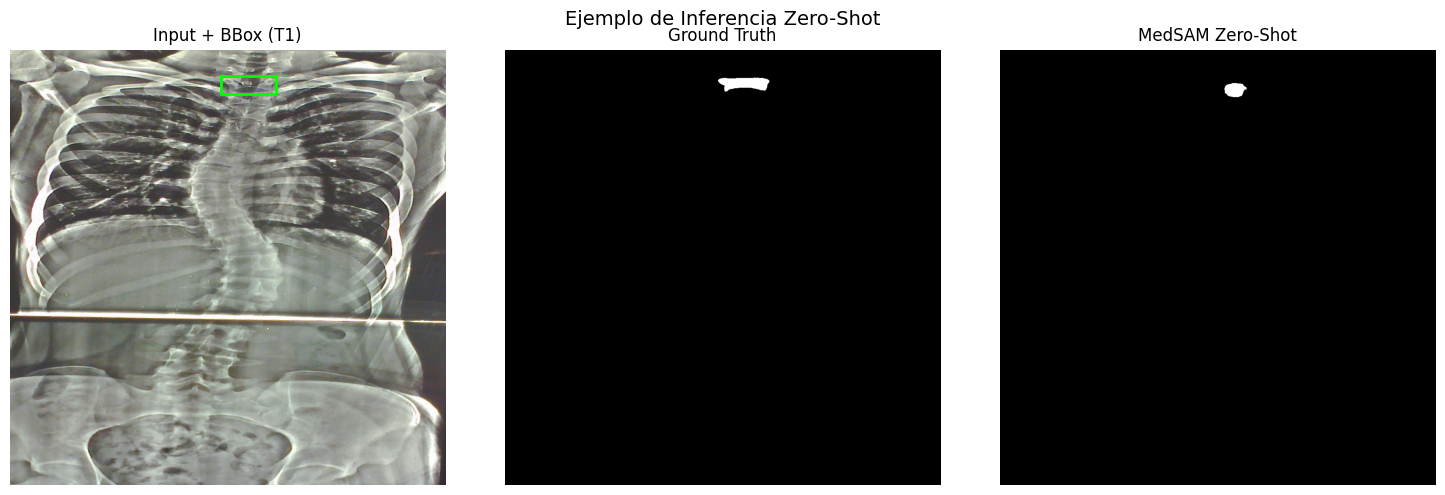

In [16]:
@torch.no_grad()
def medsam_predict(model, processor, image, bbox, device=DEVICE):
    """
    Realiza predicción con MedSAM usando un bounding box como prompt.
    Retorna máscara binaria predicha.
    """
    inputs = processor(
        images=image,
        input_boxes=[[bbox]],
        return_tensors='pt'
    ).to(device)

    outputs = model(**inputs, multimask_output=False)

    masks = processor.image_processor.post_process_masks(
        outputs.pred_masks.cpu(),
        inputs['original_sizes'].cpu(),
        inputs['reshaped_input_sizes'].cpu()
    )
    pred_mask = masks[0].squeeze().numpy()
    return (pred_mask > 0.5).astype(np.uint8)


# ── Ejemplo visual ──
sample = val_samples[0]
pred = medsam_predict(model, processor, sample['image'], sample['bbox'])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(sample['image'])
x1, y1, x2, y2 = sample['bbox']
rect = plt.Rectangle((x1,y1), x2-x1, y2-y1, lw=2, ec='lime', fc='none')
axes[0].add_patch(rect)
axes[0].set_title(f'Input + BBox ({sample["class_name"]})')
axes[0].axis('off')

axes[1].imshow(sample['mask'], cmap='gray')
axes[1].set_title('Ground Truth')
axes[1].axis('off')

axes[2].imshow(pred, cmap='gray')
axes[2].set_title('MedSAM Zero-Shot')
axes[2].axis('off')

plt.suptitle('Ejemplo de Inferencia Zero-Shot', fontsize=14)
plt.tight_layout()
plt.show()

## 5 — Métricas y Evaluación Zero-Shot

In [17]:
def compute_dice(pred, gt):
    """Calcula el coeficiente Dice."""
    pred, gt = pred.astype(bool), gt.astype(bool)
    intersection = np.logical_and(pred, gt).sum()
    if pred.sum() + gt.sum() == 0:
        return 1.0
    return 2.0 * intersection / (pred.sum() + gt.sum())


def compute_iou(pred, gt):
    """Calcula IoU (Jaccard)."""
    pred, gt = pred.astype(bool), gt.astype(bool)
    intersection = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    if union == 0:
        return 1.0
    return intersection / union


def evaluate_dataset(model, processor, samples, device=DEVICE):
    """Evalúa MedSAM en un conjunto de muestras. Retorna métricas por clase."""
    results = {name: {'dice': [], 'iou': []} for name in CLASS_NAMES}

    for s in tqdm(samples, desc='Evaluando'):
        pred = medsam_predict(model, processor, s['image'], s['bbox'], device)
        if pred.shape != s['mask'].shape:
            pred = cv2.resize(pred, (s['mask'].shape[1], s['mask'].shape[0]),
                              interpolation=cv2.INTER_NEAREST)
        results[s['class_name']]['dice'].append(compute_dice(pred, s['mask']))
        results[s['class_name']]['iou'].append(compute_iou(pred, s['mask']))

    summary = {}
    for name in CLASS_NAMES:
        if results[name]['dice']:
            summary[name] = {
                'dice': np.mean(results[name]['dice']),
                'iou':  np.mean(results[name]['iou']),
                'n':    len(results[name]['dice'])
            }
    all_d = [v['dice'] for v in summary.values()]
    all_i = [v['iou'] for v in summary.values()]
    summary['MEAN'] = {'dice': np.mean(all_d), 'iou': np.mean(all_i),
                       'n': sum(v['n'] for v in summary.values())}
    return summary


def print_results(summary, title='Resultados'):
    print(f'\n{"="*55}')
    print(f'  {title}')
    print(f'{"="*55}')
    print(f'{"Clase":>8} {"Dice":>8} {"IoU":>8} {"N":>6}')
    print(f'{"-"*34}')
    for name in CLASS_NAMES:
        if name in summary:
            s = summary[name]
            print(f'{name:>8} {s["dice"]:8.4f} {s["iou"]:8.4f} {s["n"]:6d}')
    print(f'{"-"*34}')
    m = summary['MEAN']
    print(f'{"MEAN":>8} {m["dice"]:8.4f} {m["iou"]:8.4f} {m["n"]:6d}')


# ── Evaluación Zero-Shot en validación ──
print('Evaluando MedSAM Zero-Shot en validación...')
zs_results = evaluate_dataset(model, processor, val_samples)
print_results(zs_results, 'MedSAM Zero-Shot — Validación')

Evaluando MedSAM Zero-Shot en validación...


Evaluando: 100%|██████████| 402/402 [02:52<00:00,  2.33it/s]


  MedSAM Zero-Shot — Validación
   Clase     Dice      IoU      N
----------------------------------
      T1   0.5184   0.3566     23
      T2   0.5290   0.3717     25
      T3   0.5550   0.3984     25
      T4   0.5184   0.3599     25
      T5   0.5313   0.3799     25
      T6   0.5476   0.3963     25
      T7   0.5578   0.3963     25
      T8   0.5779   0.4171     25
      T9   0.6300   0.4657     25
     T10   0.6272   0.4678     25
     T11   0.6407   0.4836     25
     T12   0.6397   0.4796     25
      L1   0.5887   0.4354     25
      L2   0.5715   0.4262     25
      L3   0.5081   0.3805     23
      L4   0.5010   0.3588     17
      L5   0.3926   0.2634     14
----------------------------------
    MEAN   0.5550   0.4022    402


## 6 — Fine-Tuning del Mask Decoder

| Componente | ¿Se entrena? | Por qué |
|---|---|---|
| `vision_encoder` | ❄️ Congelado | Preservar features de 1.5M imágenes médicas |
| `prompt_encoder` | ❄️ Congelado | Las bounding boxes no necesitan re-aprender |
| `mask_decoder` | 🔥 Se entrena | Adaptar la generación de máscaras a vértebras |

In [18]:
from torch.utils.data import Dataset, DataLoader
from monai.losses import DiceCELoss


class VertebraDataset(Dataset):
    """Dataset para fine-tuning de MedSAM con augmentación."""

    def __init__(self, samples, processor, augment=False):
        self.samples   = samples
        self.processor = processor
        self.augment   = augment

    def __len__(self):
        return len(self.samples)

    def _augment(self, img, mask, bbox):
        h, w = img.shape[:2]
        # Flip horizontal (50%)
        if random.random() > 0.5:
            img  = np.fliplr(img).copy()
            mask = np.fliplr(mask).copy()
            x1, y1, x2, y2 = bbox
            bbox = [w - x2, y1, w - x1, y2]
        # Brillo ±20%
        if random.random() > 0.5:
            factor = random.uniform(0.8, 1.2)
            img = np.clip(img * factor, 0, 255).astype(np.uint8)
        # Rotación ±15°
        if random.random() > 0.5:
            angle = random.uniform(-15, 15)
            M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
            img  = cv2.warpAffine(img,  M, (w, h), flags=cv2.INTER_LINEAR)
            mask = cv2.warpAffine(mask, M, (w, h), flags=cv2.INTER_NEAREST)
            new_bbox = get_bbox_from_mask(mask, margin=5)
            if new_bbox is not None and mask.sum() > 50:
                bbox = new_bbox
            else:
                return None
        return img, mask, bbox

    def __getitem__(self, idx):
        s = self.samples[idx]
        img  = s['image'].copy()
        mask = s['mask'].copy()
        bbox = list(s['bbox'])

        if self.augment:
            result = self._augment(img, mask, bbox)
            if result is not None:
                img, mask, bbox = result

        inputs = self.processor(
            images=img,
            input_boxes=[[bbox]],
            return_tensors='pt'
        )

        pixel_values = inputs['pixel_values'].squeeze(0)
        input_boxes  = inputs['input_boxes'].squeeze(0)

        gt_mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)
        gt_mask = torch.from_numpy(gt_mask).float().unsqueeze(0)

        return pixel_values, input_boxes, gt_mask


# ── Crear datasets y dataloaders ──
train_dataset = VertebraDataset(train_samples, processor, augment=True)
val_dataset   = VertebraDataset(val_samples,   processor, augment=False)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=2, shuffle=False, num_workers=2)

print(f'Train samples: {len(train_dataset)}')
print(f'Val samples:   {len(val_dataset)}')

2026-05-15 03:29:10.386692: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778815750.637216      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778815750.706256      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778815751.338061      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778815751.338092      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778815751.338095      57 computation_placer.cc:177] computation placer alr

Train samples: 1809
Val samples:   402


In [19]:
# ── Congelar vision_encoder y prompt_encoder ──
for param in model.vision_encoder.parameters():
    param.requires_grad = False
for param in model.prompt_encoder.parameters():
    param.requires_grad = False

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params     = sum(p.numel() for p in model.parameters())
print(f'Parámetros entrenables (mask_decoder): {trainable_params:,} / {total_params:,} '
      f'({100*trainable_params/total_params:.1f}%)')

# ── Loss, Optimizer, Scheduler ──
loss_fn   = DiceCELoss(sigmoid=True, squared_pred=True)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)

NUM_EPOCHS      = 15
PATIENCE        = 5
BEST_MODEL_PATH = WORK_DIR / 'medsam_finetuned_best_2.pth'

print(f'\nHiperparámetros:')
print(f'  Epochs:   {NUM_EPOCHS}')
print(f'  LR:       1e-4 → 1e-6 (Cosine)')
print(f'  Loss:     DiceCELoss')
print(f'  Patience: {PATIENCE}')

Parámetros entrenables (mask_decoder): 4,058,596 / 93,735,984 (4.3%)

Hiperparámetros:
  Epochs:   30
  LR:       1e-4 → 1e-6 (Cosine)
  Loss:     DiceCELoss
  Patience: 8


In [20]:
# ── Training Loop ──
best_val_loss = float('inf')
patience_counter = 0
train_losses = []
val_losses   = []

for epoch in range(NUM_EPOCHS):
    # ── Train ──
    model.train()
    epoch_train_loss = 0
    for pixel_values, input_boxes, gt_masks in tqdm(
        train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [Train]', leave=False
    ):
        pixel_values = pixel_values.to(DEVICE)
        input_boxes  = input_boxes.to(DEVICE)
        gt_masks     = gt_masks.to(DEVICE)

        outputs = model(
            pixel_values=pixel_values,
            input_boxes=input_boxes,
            multimask_output=False
        )
        pred_masks = outputs.pred_masks.squeeze(2)  # (B, 1, 256, 256)

        loss = loss_fn(pred_masks, gt_masks)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            filter(lambda p: p.requires_grad, model.parameters()), max_norm=1.0
        )
        optimizer.step()
        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ── Validation ──
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for pixel_values, input_boxes, gt_masks in tqdm(
            val_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [Val]', leave=False
        ):
            pixel_values = pixel_values.to(DEVICE)
            input_boxes  = input_boxes.to(DEVICE)
            gt_masks     = gt_masks.to(DEVICE)

            outputs = model(
                pixel_values=pixel_values,
                input_boxes=input_boxes,
                multimask_output=False
            )
            pred_masks = outputs.pred_masks.squeeze(2)
            loss = loss_fn(pred_masks, gt_masks)
            epoch_val_loss += loss.item()

    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    scheduler.step()

    # ── Logging ──
    lr_now = scheduler.get_last_lr()[0]
    print(f'  Epoch {epoch+1:3d} | Train: {avg_train_loss:.4f} | '
          f'Val: {avg_val_loss:.4f} | LR: {lr_now:.2e}', end='')

    # ── Early Stopping ──
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.mask_decoder.state_dict(), BEST_MODEL_PATH)
        print(f' ← best')
    else:
        patience_counter += 1
        print(f' (patience {patience_counter}/{PATIENCE})')
        if patience_counter >= PATIENCE:
            print(f'\n⚠️ Early stopping en epoch {epoch+1}')
            break

print(f'\n✔ Entrenamiento completado. Mejor val_loss: {best_val_loss:.4f}')

  Epoch   1 | Train: 0.1359 | Val: 0.1173 | LR: 9.97e-05 ← best


  Epoch   2 | Train: 0.0932 | Val: 0.0798 | LR: 9.89e-05 ← best


  Epoch   3 | Train: 0.0854 | Val: 0.0787 | LR: 9.76e-05 ← best


  Epoch   4 | Train: 0.0806 | Val: 0.0756 | LR: 9.57e-05 ← best


  Epoch   5 | Train: 0.0756 | Val: 0.0699 | LR: 9.34e-05 ← best


...

  Epoch  26 | Train: 0.0466 | Val: 0.0547 | LR: 5.28e-06 (patience 3/8)


  Epoch  27 | Train: 0.0457 | Val: 0.0542 | LR: 3.42e-06 ← best


  Epoch  28 | Train: 0.0452 | Val: 0.0542 | LR: 2.08e-06 ← best


  Epoch  29 | Train: 0.0448 | Val: 0.0538 | LR: 1.27e-06 ← best


KeyboardInterrupt: 

In [ ]:
# ── Curvas de Aprendizaje ──
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(range(1, len(train_losses)+1), train_losses, 'b-o', label='Train Loss', markersize=4)
ax.plot(range(1, len(val_losses)+1),   val_losses,   'r-o', label='Val Loss',   markersize=4)
ax.set_xlabel('Epoch')
ax.set_ylabel('DiceCE Loss')
ax.set_title('Curvas de Aprendizaje — Fine-Tuning MedSAM Mask Decoder')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7 — Evaluación Post Fine-Tuning

In [21]:
# ── Cargar mejores pesos ──
model.mask_decoder.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()
print('✔ Mejores pesos cargados')

# ── Evaluar en validación ──
print('\nEvaluando MedSAM Fine-Tuned en validación...')
ft_results = evaluate_dataset(model, processor, val_samples)
print_results(ft_results, 'MedSAM Fine-Tuned — Validación')

✔ Mejores pesos cargados

Evaluando MedSAM Fine-Tuned en validación...


Evaluando: 100%|██████████| 402/402 [02:58<00:00,  2.25it/s]


  MedSAM Fine-Tuned — Validación
   Clase     Dice      IoU      N
----------------------------------
      T1   0.9046   0.8271     23
      T2   0.9066   0.8306     25
      T3   0.9194   0.8520     25
      T4   0.9142   0.8436     25
      T5   0.9202   0.8532     25
      T6   0.9221   0.8576     25
      T7   0.9182   0.8499     25
      T8   0.9211   0.8552     25
      T9   0.9241   0.8609     25
     T10   0.9281   0.8668     25
     T11   0.9269   0.8647     25
     T12   0.9309   0.8716     25
      L1   0.9273   0.8654     25
      L2   0.9248   0.8621     25
      L3   0.9164   0.8490     23
      L4   0.9176   0.8499     17
      L5   0.9226   0.8571     14
----------------------------------
    MEAN   0.9203   0.8539    402


In [22]:
# ── Tabla comparativa Zero-Shot vs Fine-Tuned ──
print(f'\n{"="*65}')
print(f'  Comparación Zero-Shot vs Fine-Tuned')
print(f'{"="*65}')
print(f'{"Clase":>8} {"ZS Dice":>9} {"FT Dice":>9} {"Δ Dice":>9} '
      f'{"ZS IoU":>8} {"FT IoU":>8} {"Δ IoU":>8}')
print(f'{"-"*65}')

for name in CLASS_NAMES:
    if name in zs_results and name in ft_results:
        zd = zs_results[name]['dice']
        fd = ft_results[name]['dice']
        zi = zs_results[name]['iou']
        fi = ft_results[name]['iou']
        dd = fd - zd
        di = fi - zi
        ad = '↑' if dd > 0 else '↓' if dd < 0 else '→'
        ai = '↑' if di > 0 else '↓' if di < 0 else '→'
        print(f'{name:>8} {zd:9.4f} {fd:9.4f} {ad}{abs(dd):7.4f} '
              f'{zi:8.4f} {fi:8.4f} {ai}{abs(di):6.4f}')

print(f'{"-"*65}')
zm, fm = zs_results['MEAN'], ft_results['MEAN']
dd = fm['dice'] - zm['dice']
di = fm['iou'] - zm['iou']
ad = '↑' if dd > 0 else '↓'
ai = '↑' if di > 0 else '↓'
print(f'{"MEAN":>8} {zm["dice"]:9.4f} {fm["dice"]:9.4f} {ad}{abs(dd):7.4f} '
      f'{zm["iou"]:8.4f} {fm["iou"]:8.4f} {ai}{abs(di):6.4f}')


  Comparación Zero-Shot vs Fine-Tuned
   Clase   ZS Dice   FT Dice    Δ Dice   ZS IoU   FT IoU    Δ IoU
-----------------------------------------------------------------
      T1    0.5184    0.9046 ↑ 0.3862   0.3566   0.8271 ↑0.4705
      T2    0.5290    0.9066 ↑ 0.3776   0.3717   0.8306 ↑0.4589
      T3    0.5550    0.9194 ↑ 0.3644   0.3984   0.8520 ↑0.4536
      T4    0.5184    0.9142 ↑ 0.3958   0.3599   0.8436 ↑0.4837
      T5    0.5313    0.9202 ↑ 0.3890   0.3799   0.8532 ↑0.4734
      T6    0.5476    0.9221 ↑ 0.3746   0.3963   0.8576 ↑0.4613
      T7    0.5578    0.9182 ↑ 0.3604   0.3963   0.8499 ↑0.4536
      T8    0.5779    0.9211 ↑ 0.3431   0.4171   0.8552 ↑0.4382
      T9    0.6300    0.9241 ↑ 0.2941   0.4657   0.8609 ↑0.3953
     T10    0.6272    0.9281 ↑ 0.3010   0.4678   0.8668 ↑0.3990
     T11    0.6407    0.9269 ↑ 0.2862   0.4836   0.8647 ↑0.3811
     T12    0.6397    0.9309 ↑ 0.2912   0.4796   0.8716 ↑0.3920
      L1    0.5887    0.9273 ↑ 0.3386   0.4354   0.8654 ↑0.43

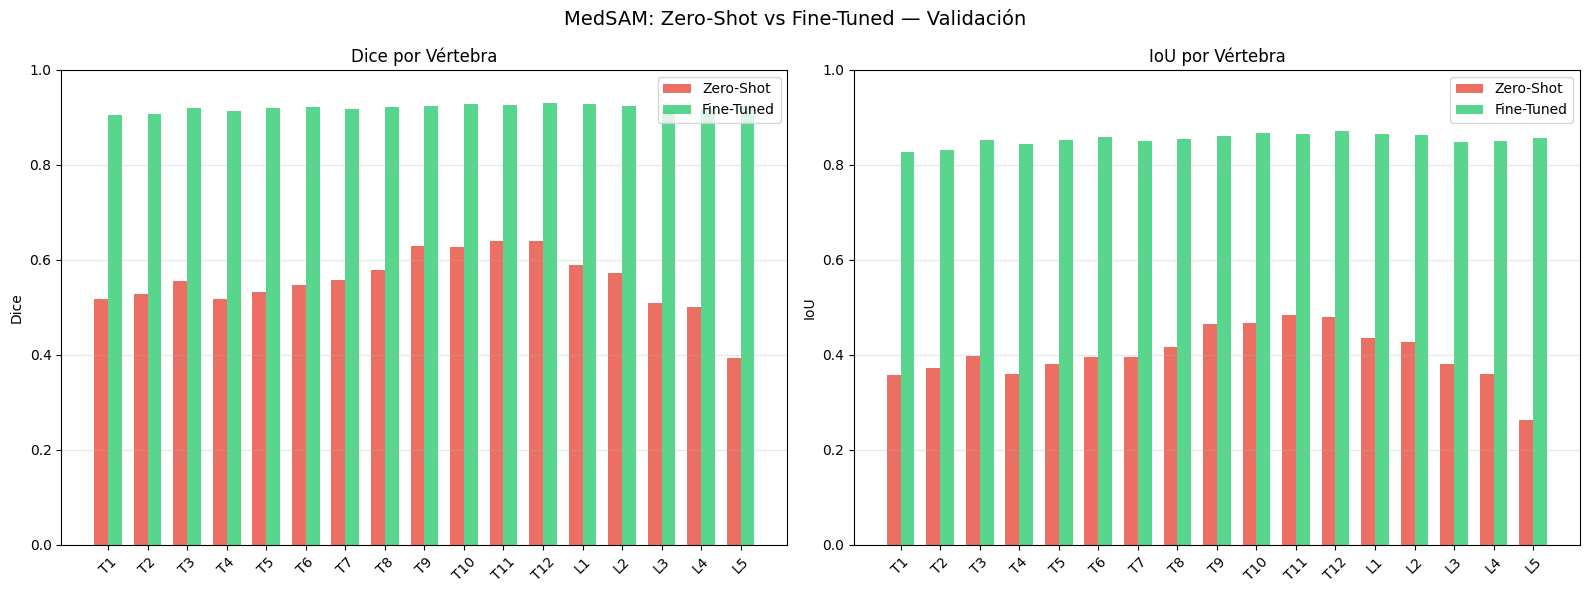

In [23]:
# ── Bar Chart Comparativo ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(NUM_CLASSES)
width = 0.35

zs_d = [zs_results.get(n, {}).get('dice', 0) for n in CLASS_NAMES]
ft_d = [ft_results.get(n, {}).get('dice', 0) for n in CLASS_NAMES]
zs_i = [zs_results.get(n, {}).get('iou', 0) for n in CLASS_NAMES]
ft_i = [ft_results.get(n, {}).get('iou', 0) for n in CLASS_NAMES]

axes[0].bar(x - width/2, zs_d, width, label='Zero-Shot', color='#e74c3c', alpha=0.8)
axes[0].bar(x + width/2, ft_d, width, label='Fine-Tuned', color='#2ecc71', alpha=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(CLASS_NAMES, rotation=45)
axes[0].set_ylabel('Dice'); axes[0].set_title('Dice por Vértebra')
axes[0].legend(); axes[0].set_ylim(0, 1); axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x - width/2, zs_i, width, label='Zero-Shot', color='#e74c3c', alpha=0.8)
axes[1].bar(x + width/2, ft_i, width, label='Fine-Tuned', color='#2ecc71', alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(CLASS_NAMES, rotation=45)
axes[1].set_ylabel('IoU'); axes[1].set_title('IoU por Vértebra')
axes[1].legend(); axes[1].set_ylim(0, 1); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('MedSAM: Zero-Shot vs Fine-Tuned — Validación', fontsize=14)
plt.tight_layout()
plt.show()

## 8 — Evaluación Final en Test

In [24]:
print('Evaluando MedSAM Fine-Tuned en test...')
test_results = evaluate_dataset(model, processor, test_samples)
print_results(test_results, 'MedSAM Fine-Tuned — Test')

Evaluando MedSAM Fine-Tuned en test...


Evaluando: 100%|██████████| 388/388 [02:51<00:00,  2.26it/s]


  MedSAM Fine-Tuned — Test
   Clase     Dice      IoU      N
----------------------------------
      T1   0.9102   0.8366     25
      T2   0.8843   0.8052     25
      T3   0.9122   0.8399     25
      T4   0.9055   0.8302     25
      T5   0.9126   0.8408     25
      T6   0.9154   0.8454     25
      T7   0.9257   0.8627     24
      T8   0.9251   0.8624     25
      T9   0.9181   0.8542     25
     T10   0.9303   0.8711     25
     T11   0.9357   0.8806     25
     T12   0.9143   0.8557     25
      L1   0.9269   0.8682     24
      L2   0.9257   0.8647     22
      L3   0.9486   0.9026     17
      L4   0.9321   0.8740     16
      L5   0.9007   0.8208     10
----------------------------------
    MEAN   0.9190   0.8538    388


## 9 — Comparación Visual

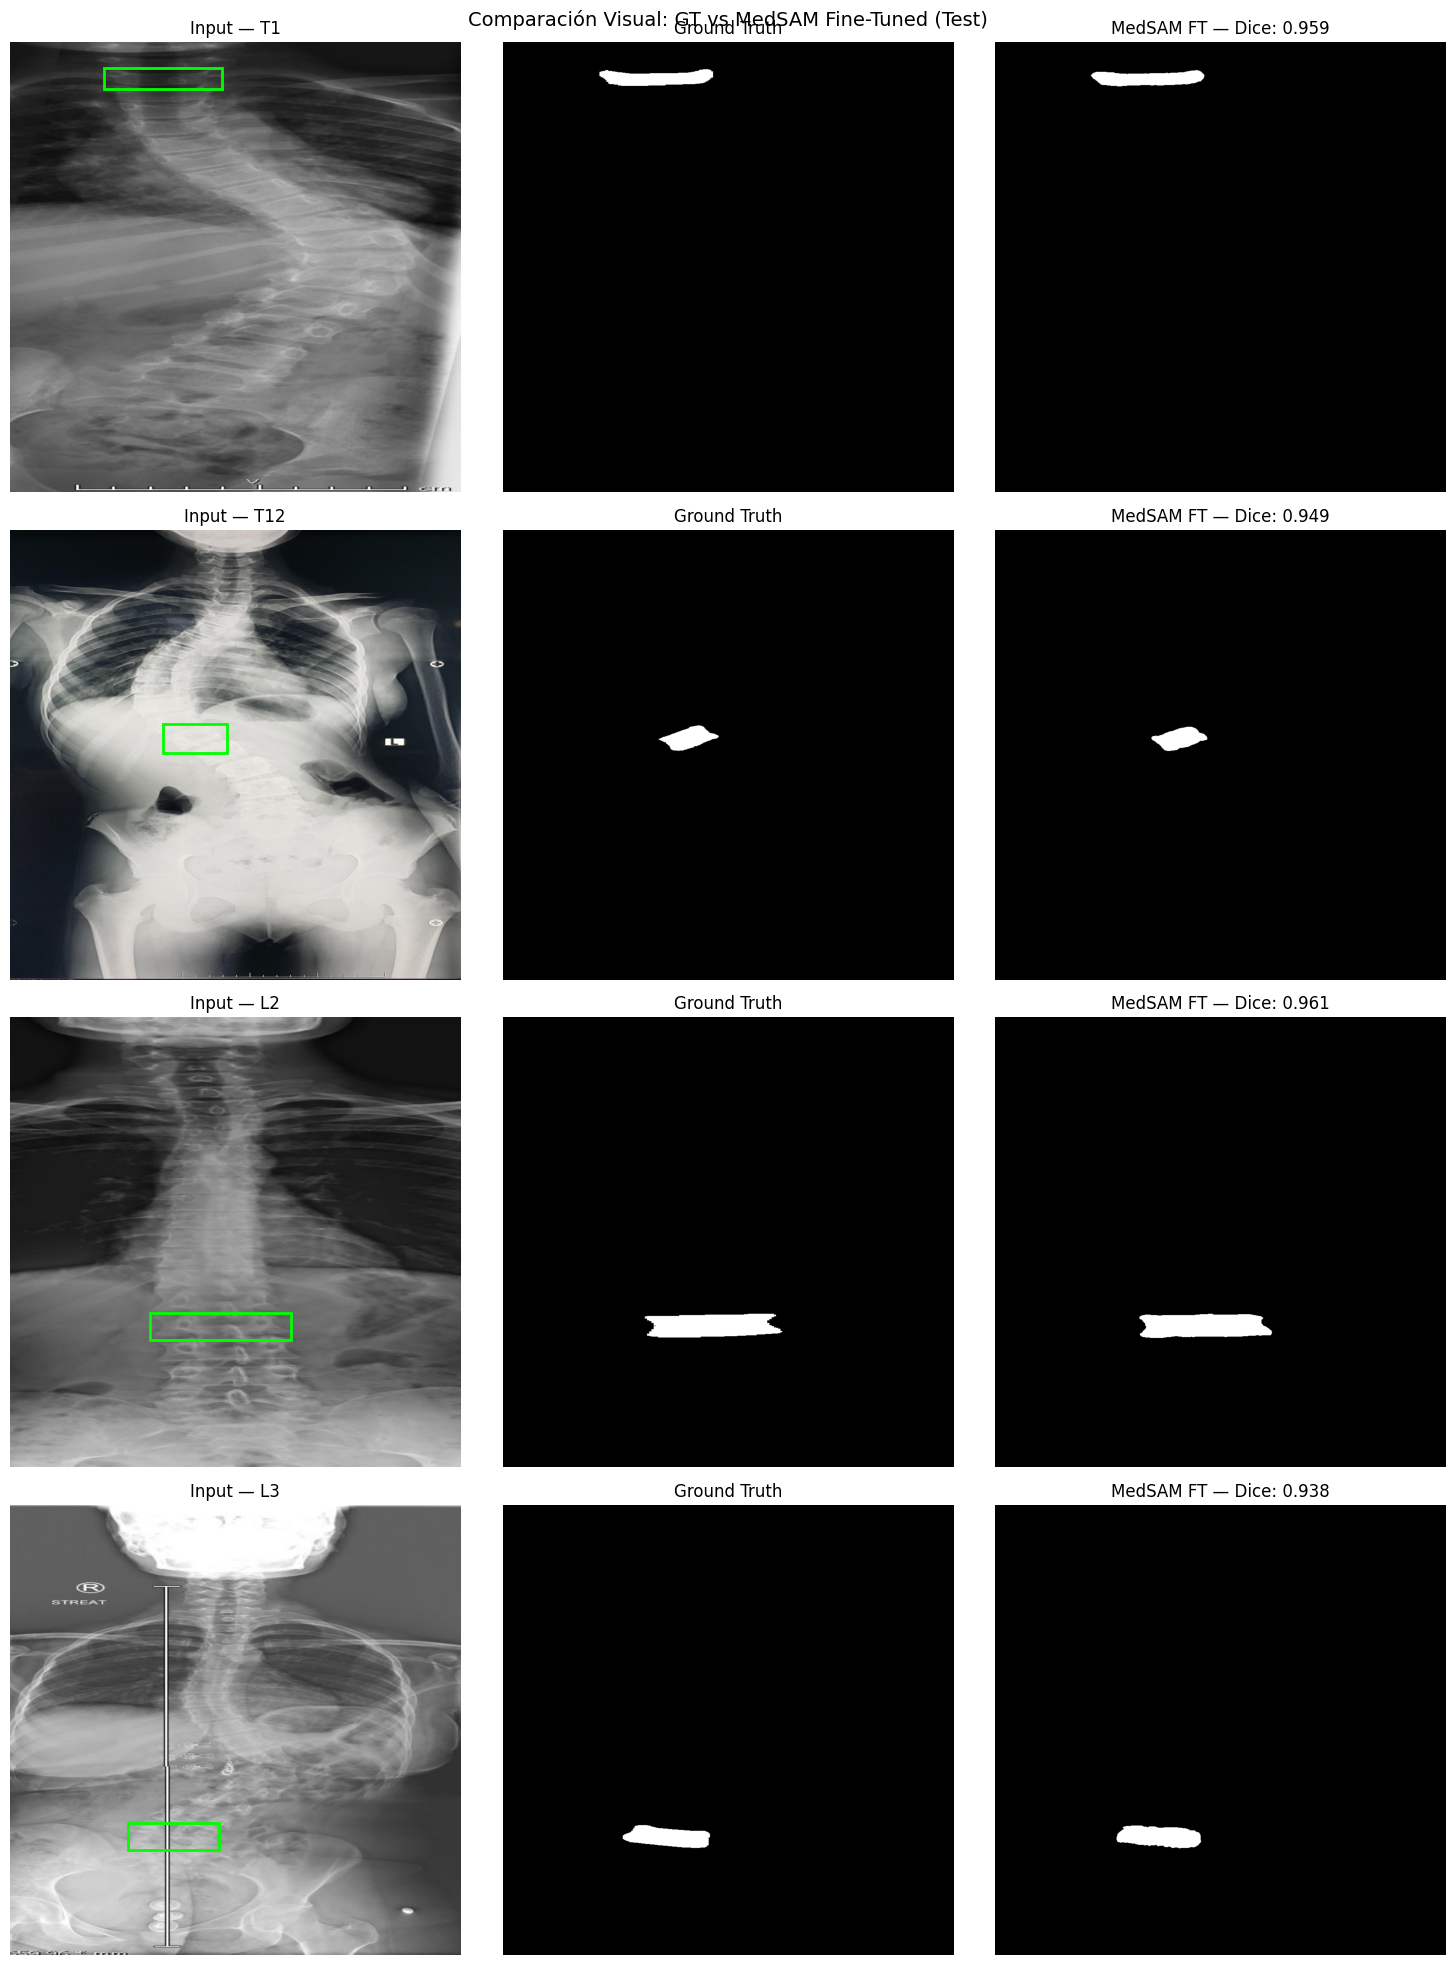

In [25]:
viz_indices = np.linspace(0, len(test_samples)-1, 4, dtype=int)

fig, axes = plt.subplots(4, 3, figsize=(15, 20))
for row, idx in enumerate(viz_indices):
    s = test_samples[idx]
    pred = medsam_predict(model, processor, s['image'], s['bbox'])
    if pred.shape != s['mask'].shape:
        pred = cv2.resize(pred, (s['mask'].shape[1], s['mask'].shape[0]),
                          interpolation=cv2.INTER_NEAREST)
    dice = compute_dice(pred, s['mask'])

    axes[row, 0].imshow(s['image'])
    x1, y1, x2, y2 = s['bbox']
    rect = plt.Rectangle((x1,y1), x2-x1, y2-y1, lw=2, ec='lime', fc='none')
    axes[row, 0].add_patch(rect)
    axes[row, 0].set_title(f'Input — {s["class_name"]}')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(s['mask'], cmap='gray')
    axes[row, 1].set_title('Ground Truth')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(pred, cmap='gray')
    axes[row, 2].set_title(f'MedSAM FT — Dice: {dice:.3f}')
    axes[row, 2].axis('off')

plt.suptitle('Comparación Visual: GT vs MedSAM Fine-Tuned (Test)', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ── Guardar y subir pesos fine-tuned a HuggingFace ──
import torch
from huggingface_hub import HfApi

# 1. Guardar pesos del mask decoder (los que entrenamos)
SAVE_PATH = "/kaggle/working/medsam_spine_finetuned.pth"
torch.save(model.mask_decoder.state_dict(), SAVE_PATH)
print(f"✔ Pesos guardados localmente: {SAVE_PATH}")

# 2. Subir a HuggingFace
api = HfApi()
api.upload_file(
    path_or_fileobj=SAVE_PATH,
    path_in_repo="medsam_spine_finetuned.pth",
    repo_id="javiercamilogarcia/submissions",
    repo_type="dataset",
    token="TU-TOKEN"  # ← pega tu token aquí
)
print("✔ Pesos subidos a HuggingFace")


# ── Descargar pesos desde HuggingFace ──
from huggingface_hub import hf_hub_download

weights_path = hf_hub_download(
    repo_id="javiercamilogarcia/submissions",
    filename="medsam_spine_finetuned.pth",
    repo_type="dataset"
)
print(f"Descargado en: {weights_path}")

# Cargar en el modelo
model.mask_decoder.load_state_dict(torch.load(weights_path, map_location=DEVICE))
model.eval()
print("✔ Pesos cargados")


✔ Pesos guardados localmente: /kaggle/working/medsam_spine_finetuned.pth


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

✔ Pesos subidos a HuggingFace


medsam_spine_finetuned.pth:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

Descargado en: /root/.cache/huggingface/hub/datasets--javiercamilogarcia--submissions/snapshots/bdf86be673b7227cf3a57d71cc29bcfab3854411/medsam_spine_finetuned.pth
✔ Pesos cargados


✔ Funciones corregidas
✔ Funciones optimizadas definidas


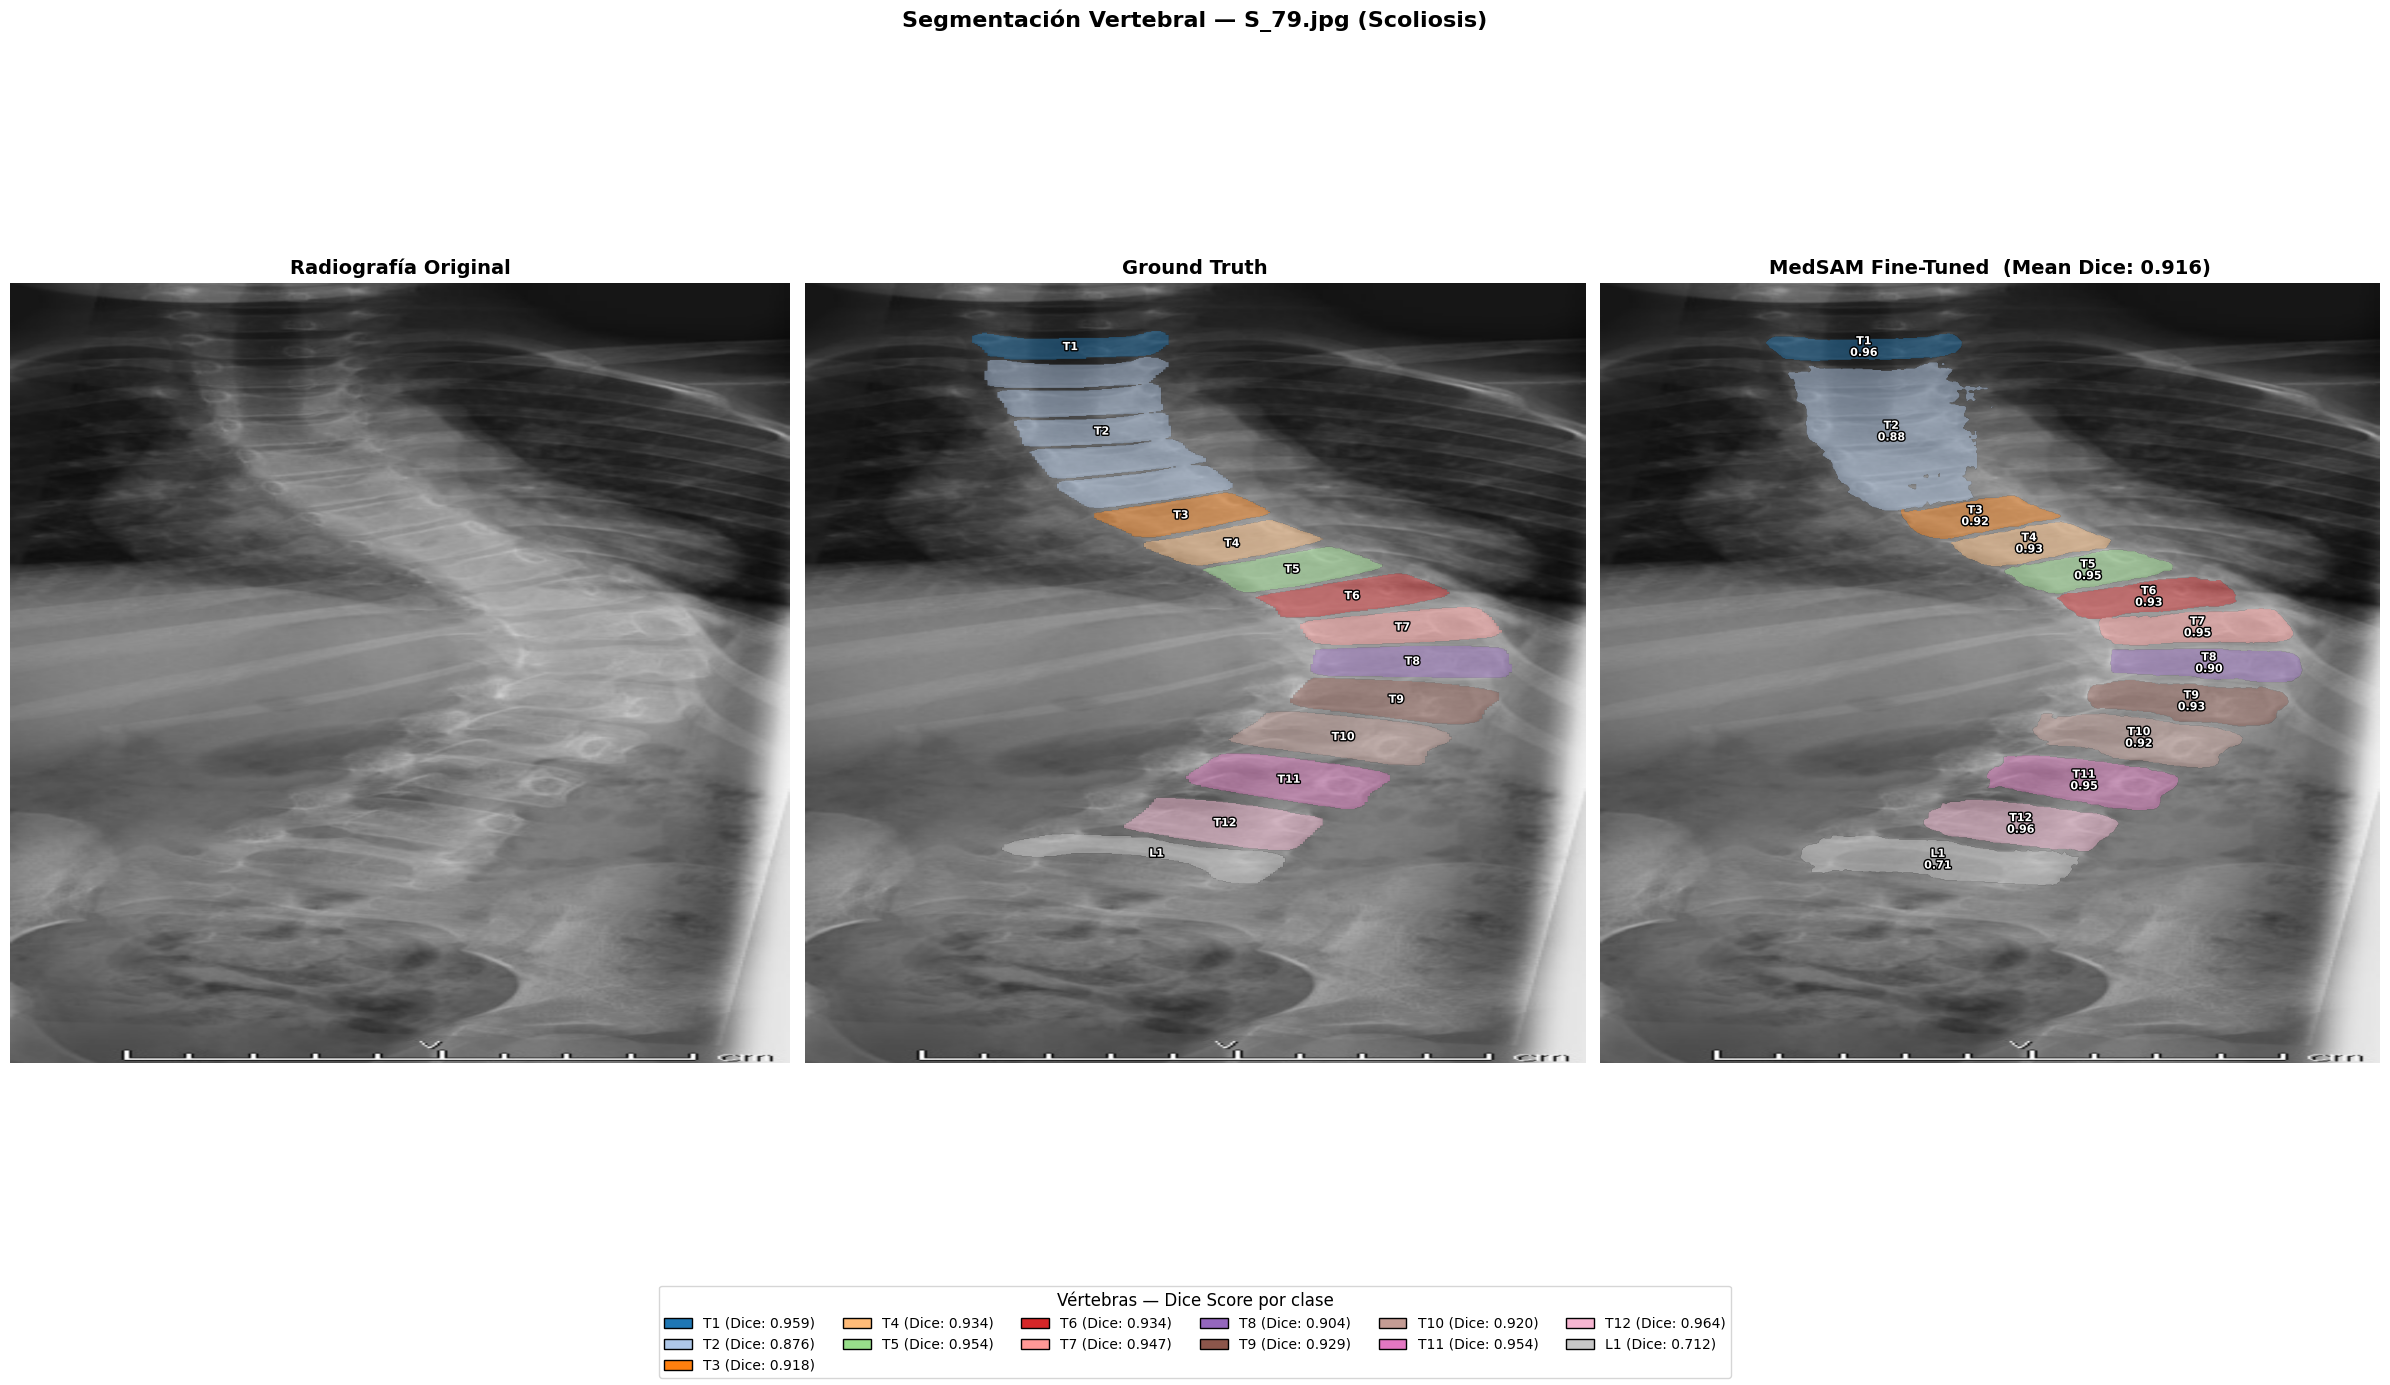


  Dice por vértebra — S_79.jpg
    T1: 0.9586 ███████████████████
    T2: 0.8756 █████████████████
    T3: 0.9185 ██████████████████
    T4: 0.9343 ██████████████████
    T5: 0.9544 ███████████████████
    T6: 0.9337 ██████████████████
    T7: 0.9474 ██████████████████
    T8: 0.9042 ██████████████████
    T9: 0.9291 ██████████████████
   T10: 0.9197 ██████████████████
   T11: 0.9537 ███████████████████
   T12: 0.9645 ███████████████████
    L1: 0.7124 ██████████████
────────────────────────────────────────
  MEAN: 0.9159


In [32]:
# ══════════════════════════════════════════════════════════════════════
# 🎨 Visualización: Segmentación multiclase de TODAS las vértebras
# ══════════════════════════════════════════════════════════════════════

import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import matplotlib.patheffects as pe

# ── Funciones de predicción OPTIMIZADA ──

@torch.no_grad()
def get_image_embedding(model, processor, image):
    """Pre-calcula el embedding (1 sola vez por imagen)."""
    inputs = processor(images=image, return_tensors='pt').to(DEVICE)
    image_embedding = model.get_image_embeddings(inputs['pixel_values'])
    return image_embedding, inputs

@torch.no_grad()
def medsam_predict_fast(model, processor, image_embedding, original_image, bbox):
    """Predicción rápida usando embedding pre-calculado."""
    # Procesar con la imagen REAL para que las coordenadas del bbox
    # se escalen correctamente (esto es rápido, solo CPU)
    inputs = processor(
        images=original_image,
        input_boxes=[[bbox]],
        return_tensors='pt'
    ).to(DEVICE)

    outputs = model(
        image_embeddings=image_embedding,
        input_boxes=inputs['input_boxes'],
        multimask_output=False
    )

    masks = processor.image_processor.post_process_masks(
        outputs.pred_masks.cpu(),
        inputs['original_sizes'].cpu(),
        inputs['reshaped_input_sizes'].cpu()
    )
    pred = masks[0].squeeze().numpy()
    return (pred > 0.5).astype(np.uint8)

print('✔ Funciones corregidas')

print('✔ Funciones optimizadas definidas')

# ── Paleta de 17 colores distintos para T1-L5 ──
cmap = plt.cm.get_cmap('tab20', NUM_CLASSES)
COLORS = [cmap(i)[:3] for i in range(NUM_CLASSES)]

def visualize_full_segmentation(model, processor, row, device=DEVICE):
    """
    Visualiza la segmentación de TODAS las vértebras en una imagen:
    Original | Ground Truth | MedSAM Predicción
    """
    # 1. Cargar imagen y máscara
    img, mask = load_image_and_mask(row)
    img_r, mask_r = resize_for_medsam(img, mask)
    
    # 2. Pre-calcular embedding (1 sola vez)
    img_emb, inputs = get_image_embedding(model, processor, img_r)
    
    # 3. Crear overlays vacíos
    h, w = img_r.shape[:2]
    gt_overlay   = np.zeros((h, w, 4), dtype=np.float32)  # RGBA
    pred_overlay = np.zeros((h, w, 4), dtype=np.float32)
    
    # 4. Para cada vértebra: predecir y colorear
    dice_scores = {}
    gt_centroids = {}
    pred_centroids = {}
    
    for cls_id in range(1, NUM_CLASSES + 1):
        cls_name = CLASS_NAMES[cls_id - 1]
        binary_gt = (mask_r == cls_id).astype(np.uint8)
        
        if binary_gt.sum() < 50:
            continue
        
        bbox = get_bbox_from_mask(binary_gt, margin=5)
        if bbox is None:
            continue
        pred = medsam_predict_fast(model, processor, img_emb, img_r, bbox)
        if pred.shape != binary_gt.shape:
            pred = cv2.resize(pred, (w, h), interpolation=cv2.INTER_NEAREST)
        
        dice_scores[cls_name] = compute_dice(pred, binary_gt)
        
        color = COLORS[cls_id - 1]
        alpha = 0.45
        
        # Overlay GT
        gt_mask_bool = binary_gt > 0
        gt_overlay[gt_mask_bool, 0] = color[0]
        gt_overlay[gt_mask_bool, 1] = color[1]
        gt_overlay[gt_mask_bool, 2] = color[2]
        gt_overlay[gt_mask_bool, 3] = alpha
        
        # Overlay Predicción
        pred_mask_bool = pred > 0
        pred_overlay[pred_mask_bool, 0] = color[0]
        pred_overlay[pred_mask_bool, 1] = color[1]
        pred_overlay[pred_mask_bool, 2] = color[2]
        pred_overlay[pred_mask_bool, 3] = alpha
        
        # Centroides para etiquetas
        ys, xs = np.where(gt_mask_bool)
        if len(xs) > 0:
            gt_centroids[cls_name] = (int(xs.mean()), int(ys.mean()))
        
        ys2, xs2 = np.where(pred_mask_bool)
        if len(xs2) > 0:
            pred_centroids[cls_name] = (int(xs2.mean()), int(ys2.mean()))
    
    # 5. Crear figura
    fig, axes = plt.subplots(1, 3, figsize=(24, 14))
    
    text_style = dict(
        fontsize=8, fontweight='bold', color='white', ha='center', va='center',
        path_effects=[pe.withStroke(linewidth=2, foreground='black')]
    )
    
    # Panel 1: Original
    axes[0].imshow(img_r)
    axes[0].set_title('Radiografía Original', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    # Panel 2: Ground Truth
    axes[1].imshow(img_r)
    axes[1].imshow(gt_overlay)
    for cls_name, (cx, cy) in gt_centroids.items():
        axes[1].text(cx, cy, cls_name, **text_style)
    axes[1].set_title('Ground Truth', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    # Panel 3: MedSAM Predicción
    axes[2].imshow(img_r)
    axes[2].imshow(pred_overlay)
    for cls_name, (cx, cy) in pred_centroids.items():
        dice = dice_scores.get(cls_name, 0)
        axes[2].text(cx, cy, f'{cls_name}\n{dice:.2f}', **text_style)
    mean_dice = np.mean(list(dice_scores.values())) if dice_scores else 0
    axes[2].set_title(f'MedSAM Fine-Tuned  (Mean Dice: {mean_dice:.3f})',
                      fontsize=14, fontweight='bold')
    axes[2].axis('off')
    
    # Leyenda de colores
    legend_patches = []
    for cls_id in range(1, NUM_CLASSES + 1):
        cls_name = CLASS_NAMES[cls_id - 1]
        if cls_name in dice_scores:
            color = COLORS[cls_id - 1]
            label = f'{cls_name} (Dice: {dice_scores[cls_name]:.3f})'
            legend_patches.append(Patch(facecolor=color, edgecolor='black', label=label))
    
    fig.legend(handles=legend_patches, loc='lower center', ncol=6,
               fontsize=10, frameon=True, fancybox=True,
               title='Vértebras — Dice Score por clase', title_fontsize=12)
    
    nombre_img = row.get('imagen', '')
    grupo = row.get(COL_GRUPO, '')
    fig.suptitle(f'Segmentación Vertebral — {nombre_img} ({grupo})',
                 fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout(rect=[0, 0.08, 1, 0.96])
    plt.show()
    
    # Tabla de Dice
    print(f'\n{"="*40}')
    print(f'  Dice por vértebra — {nombre_img}')
    print(f'{"="*40}')
    for cls_name, dice in dice_scores.items():
        bar = "█" * int(dice * 20)
        print(f'  {cls_name:>4s}: {dice:.4f} {bar}')
    print(f'{"─"*40}')
    print(f'  MEAN: {mean_dice:.4f}')


# ══════════════════════════════════════════════════════════════════════
# Ejecutar — cambia el índice para ver otras imágenes
# ══════════════════════════════════════════════════════════════════════
model.eval()
visualize_full_segmentation(model, processor, test_df.iloc[0])

# ── Descomenta para ver más imágenes ──
# for i in range(min(3, len(test_df))):


## 10 — Estrategias y Próximos Pasos

### Estrategias para maximizar Dice/IoU con pocos datos

| Estrategia | Impacto | Estado |
|---|---|---|
| Fine-tune solo mask decoder | Evita overfitting | ✅ Implementado |
| Augmentación (flip, rotación, brillo) | +5-10% Dice | ✅ Implementado |
| DiceCE Loss | Entrenamiento estable | ✅ Implementado |
| Gradient clipping | Previene explosión | ✅ Implementado |
| Early stopping | Evita sobreajuste | ✅ Implementado |
| Filtrado por reporte CSV | Datos limpios | ✅ Implementado |
| Elastic deformation | +2-5% Dice | 🔜 Usar `albumentations` |
| Test-Time Augmentation (TTA) | +1-3% Dice | 🔜 Promediar predicciones |
| Descongelar prompt_encoder | +2-5% Dice | 🔜 Siguiente experimento |

### Próximos pasos

1. **MedSAM2** (abril 2025) — Segmentación 3D, un prompt propaga entre slices
2. **Pipeline Híbrido** — YOLOv8 detecta bboxes → MedSAM segmenta
3. **LiteMedSAM** — 10× más rápido para despliegue en producción

### Para correr en Kaggle
1. Subir dataset como Kaggle Dataset
2. Ajustar `DATASET_ROOT` a `/kaggle/input/tu-dataset`
3. Activar GPU T4 o P100 en Settings
4. El notebook cabe en las 30h/semana gratuitas